# Notebook 3B — Uncertainty for a Random Forest

*Day 5b · read a per-star error bar out of your forest's trees, calibrate it, and discover where it still lies.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome to your random forest's uncertainty lab

In the **common** notebook (`03_uncertainty_common`) the whole team built one *shared* constant ± band
on the linear baseline, tuned it to 90% on average, and discovered it still **under-covers luminous
giants and metal-poor stars**. Today you go back to **your** model — the **random forest** you tuned in
Notebook 2B — and give it an error bar built from its *own internals*.

The big idea for a forest: it's already **many trees that disagree**. Where they disagree a lot, the
prediction is shaky; where they agree, it's solid. That **spread across the trees** is a free, per-star
uncertainty — no extra model, no extra fit. You'll read it out, calibrate it, and stress-test it.

Here's today's arc:

1. **The shared band on your model** — the constant ± floor, for comparison.
2. **Your model's native σ(x)** — *you* implement the tree-variance recipe.
3. **The fudge factor** — *you* tune one number on the calibration set so coverage hits 90%.
4. **Did it work?** — coverage, reliability by `log g` and `[Fe/H]`, widths.
5. **Explore** — is your uncertainty aleatoric or epistemic in flavour?
6. **Save** your interval for Notebook 4.

The rhythm, as always: **Explain → Worked (run it) → Your turn (change it, look again) → Explore (play).**

> Runs top-to-bottom as shipped. Every "your turn" cell already works — the task is to *change* a marked
> value and re-run. If a cell errors, grab a TA.

**Honesty preview:** your native interval is the forest's *raw* uncertainty — **not guaranteed
calibrated**. Finding it imperfect is the *point*, and the reason for Notebook 4. Don't over-tune.

## 0 · Load your tuned random forest and its predictions

This lab is for **Student B (random forest)**, so `MODEL = "rf"` throughout. Two things come from your
earlier work in Notebook 2B:

| what | where it came from | why we need it |
|---|---|---|
| `pipe = load_model("rf")` | the **tuned** forest you `save_model`'d in 02B | we read the *trees* out of it |
| `d = load_outputs("rf_preds.npz")` | the predictions you `save_outputs`'d in 02B | the constant-band floor (§1) |

> **We load the model you tuned — we do *not* refit a fresh default.** The forest's trees live *inside*
> the saved pipeline, so the uncertainty you build is the uncertainty of *the model you actually tuned*.

One term to pin down — the **calibration set**: the held-out chunk of stars that is *neither* training
*nor* test. You set it aside in Notebook 2; today it earns its keep twice — to size the constant band
(§1) and to tune the fudge factor (§3).

In [2]:
import warnings
from scipy.stats import norm

MODEL = "rf"                              # this lab is the random-forest branch
TARGET_LEVEL = 0.90                       # we want honest 90% intervals all day
k = norm.ppf((1 + TARGET_LEVEL) / 2)      # Gaussian multiplier: ~1.645 for 90% (a z-score)
print(f"MODEL = {MODEL!r}   nominal level = {TARGET_LEVEL:.0%}   k = {k:.3f}")

# 1) The TUNED random forest you saved in Notebook 2B (NOT a fresh refit).
try:
    pipe = load_model(MODEL)                       # models/rf.joblib  (Pipeline: StandardScaler + RF)
except FileNotFoundError:
    raise FileNotFoundError(
        "Missing models/rf.joblib — run 02b_tune_random_forest first (its last section save_model's it).")

# 2) The predictions you saved in Notebook 2B (for the shared constant-band floor in §1).
try:
    d = load_outputs(f"{MODEL}_preds.npz")         # keys: y_cal_true, y_cal_pred, y_test_true, y_test_pred
except FileNotFoundError:
    raise FileNotFoundError(
        "Missing outputs/rf_preds.npz — run 02b_tune_random_forest first, then re-run this cell.")

print("pipeline steps:", list(pipe.named_steps.keys()))
print("preds keys:    ", list(d.keys()))
print(f"calibration stars: {d['y_cal_true'].size:,}    test stars: {d['y_test_true'].size:,}")

MODEL = 'rf'   nominal level = 90%   k = 1.645


pipeline steps: ['standardscaler', 'randomforestregressor']
preds keys:     ['y_cal_true', 'y_cal_pred', 'y_test_true', 'y_test_pred']
calibration stars: 6,000    test stars: 6,000


In [3]:
# Re-load the data and redo the SAME seed=0 split NB2 used, so we have the test/cal FEATURES (to feed
# the trees) and LABELS (to bin coverage by log g / [Fe/H]).  NB2 normalised BEFORE splitting, so the
# saved predictions line up row-for-row with this fresh split.
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])               # the recipe: brightness -> spectral shape
sp = train_cal_test_split(Xn, y, seed=0)            # same split convention -> rows align with saved preds

# Targets and the physical axes we'll slice coverage by.
y_test_feh = sp["y_test"]["FeH"].to_numpy()
y_cal_feh  = sp["y_cal"]["FeH"].to_numpy()
logg_test  = sp["y_test"]["logg"].to_numpy()
feh_test   = sp["y_test"]["FeH"].to_numpy()
Teff_test  = sp["y_test"]["Teff"].to_numpy()

# Tripwires: if these fire, the saved preds were built on a DIFFERENT split (fix NB2, don't relax this).
assert y_test_feh.size == d["y_test_true"].size, "split mismatch: did NB2 normalize_by_g BEFORE seed=0 split?"
assert np.allclose(y_test_feh, d["y_test_true"]), "row order mismatch with saved test preds!"
assert np.allclose(y_cal_feh,  d["y_cal_true"]),  "row order mismatch with saved cal preds!"
print("features + labels aligned with saved predictions:",
      sp["X_test"].shape[0], "test stars |", sp["X_cal"].shape[0], "cal stars")

features + labels aligned with saved predictions: 6000 test stars | 6000 cal stars


## 1 · The shared constant band on your forest (the floor to beat)

First, the simplest honest interval — the same one from the common notebook, now on **your forest's**
predictions. It's the *floor*: a single ± band you'll try to beat with a per-star one.

- A **residual** is `predicted − true` — the signed error on one star.
- Its standard deviation **σ** (measured on the **calibration** set, which the model never fit) is one
  number summarising "how far off we usually are."
- The interval is `prediction ± k·σ`, with `k ≈ 1.645` (the Gaussian multiplier bracketing the middle
  90% of a bell curve).

Its built-in weakness, stated up front: **one width for every star** (it's *homoscedastic*). It cannot
widen for the genuinely harder stars. Your forest is about to do better than that.

In [4]:
# Residuals on the HELD-OUT calibration set (honest; the forest never fit these).
resid_cal = d["y_cal_pred"] - d["y_cal_true"]            # signed errors, shape (n_cal,)
sigma_const = resid_cal.std()                            # ONE number: typical [Fe/H] error (dex)
print(f"calibration residual scatter   sigma_const = {sigma_const:.3f} dex")
print(f"calibration bias (mean error)              = {resid_cal.mean():+.3f} dex   (near 0 -> no offset)")

# The SAME +/- k*sigma band on every test star.
y_test_pred = d["y_test_pred"]
shared_lower = y_test_pred - k * sigma_const
shared_upper = y_test_pred + k * sigma_const
print(f"every shared interval has the SAME half-width = {k * sigma_const:.3f} dex   (one size fits all)")

# Did it land at 90%?  empirical_coverage = fraction of TEST truths inside the band.
cov_shared = empirical_coverage(y_test_feh, shared_lower, shared_upper)
print(f"\nshared constant interval: empirical coverage on test = {cov_shared:.1%}   "
      f"(target = {TARGET_LEVEL:.0%})")

calibration residual scatter   sigma_const = 0.182 dex
calibration bias (mean error)              = +0.001 dex   (near 0 -> no offset)
every shared interval has the SAME half-width = 0.299 dex   (one size fits all)

shared constant interval: empirical coverage on test = 91.9%   (target = 90%)


## 2 · Build your forest's native σ(x): the spread across the trees

Now the part that's *yours*. A random forest is an **ensemble of decision trees**, each trained on a
different bootstrap sample of the data and a different random subset of features. So the trees
**disagree** — and the forest's prediction is just their **average**. The genius move:

> the **spread (standard deviation) of the individual trees' predictions** is a free, per-star
> uncertainty. Trees disagree most where the data is sparse or ambiguous → larger σ there.

Two facts make this clean and exact:

- `pipe.named_steps["randomforestregressor"].estimators_` is the **list of fitted trees** (one per
  `n_estimators`).
- Averaging their predictions reproduces `pipe.predict` **exactly** — so the per-tree *spread* is a
  genuinely *extra* quantity you get for free, no refit required.

**Your turn:** fill in the one line that turns the stack of per-tree predictions into a per-star σ. The
scaffold ships working (the gap has a sensible default); the task is to make sure you understand each
piece, then move to §3.

In [5]:
# GOAL: a per-star point prediction `y_pred_native` and a per-star scale `sigma_native`,
#       both shape (n_test,), read straight out of YOUR tuned forest's trees.

# Reach inside the fitted pipeline (no refit — these trees were fit in 02B).
scaler = pipe.named_steps["standardscaler"]
rf     = pipe.named_steps["randomforestregressor"]
print(f"forest has {len(rf.estimators_)} trees")

# Each tree predicts the WHOLE test set; stack them into (n_trees, n_test).
# We must hand each tree the SAME preprocessing the pipeline uses: scaler.transform(...).
Xte_scaled = scaler.transform(sp["X_test"])
per_tree = np.stack([t.predict(Xte_scaled) for t in rf.estimators_])   # shape (n_trees, n_test)
print("per_tree shape (n_trees, n_test):", per_tree.shape)

# The forest's prediction is the trees' MEAN; the uncertainty is their SPREAD.
y_pred_native = per_tree.mean(axis=0)                  # == pipe.predict(sp["X_test"]) exactly
sigma_native  = per_tree.std(axis=0)                   # <- your turn: per-star tree spread, shape (n_test,)

# Sanity: the mean of the trees should equal the pipeline's own prediction.
assert np.allclose(y_pred_native, pipe.predict(sp["X_test"])), "tree mean should equal pipe.predict!"
assert y_pred_native.shape == sigma_native.shape == y_test_feh.shape, "all must be shape (n_test,)"

print(f"native sigma: median = {np.median(sigma_native):.3f} dex, "
      f"range = [{sigma_native.min():.3f}, {sigma_native.max():.3f}]   "
      f"(it VARIES per star, unlike the constant band)")

forest has 150 trees
per_tree shape (n_trees, n_test): (150, 6000)


native sigma: median = 0.158 dex, range = [0.036, 0.720]   (it VARIES per star, unlike the constant band)


**A concept worth knowing: quantile regression forests.** Tree-spread is one way to get uncertainty
from a forest. A fancier route is a **quantile regression forest** (Meinshausen 2006): instead of
storing only the *mean* target in each leaf, it keeps the *whole distribution* of training targets that
fall in each leaf, so it can report, say, the 5th and 95th percentiles directly — an interval that
**includes the aleatoric scatter** the plain tree-spread misses, and that often covers better out of the
box.

The package `quantile-forest` (`from quantile_forest import RandomForestQuantileRegressor`) implements
it, but it is **not installed** on our lab environment — so we'll stick with the tree-spread you just
built (it teaches the same idea with no extra dependency). If you're curious, ask a TA before importing
anything new.

In [6]:
# Turn the per-star scale into a 90% interval the naive way (c = 1, no calibration yet).
native_lower_raw = y_pred_native - k * sigma_native
native_upper_raw = y_pred_native + k * sigma_native

cov_native_raw = empirical_coverage(y_test_feh, native_lower_raw, native_upper_raw)
print(f"native interval (raw, c = 1): empirical coverage on test = {cov_native_raw:.1%}   "
      f"(target = {TARGET_LEVEL:.0%})")
print(f"compare -- shared constant band was {cov_shared:.1%}")
# <- look for: is the raw native coverage above or below 90%?  It is NOT automatically calibrated.

native interval (raw, c = 1): empirical coverage on test = 96.5%   (target = 90%)
compare -- shared constant band was 91.9%


## 3 · The fudge factor — calibrate your native σ

Your native σ gives the **shape** of the uncertainty — *which* stars are hard (big σ) and which are easy
(small σ). What it gets *wrong* is the overall **scale**: the raw band over-covered. So we keep the shape
and fix the scale with a single tunable number — a **fudge factor `c`**:

$$\text{interval} = \hat y \pm c \cdot k \cdot \sigma(x)$$

One `c` for *all* stars; it slides every interval wider (`c > 1`) or narrower (`c < 1`) together, keeping
their *relative* sizes — the per-star shape — intact.

> **The honest protocol — tune on calibration, report on test.** Pick `c` so that coverage on the
> **calibration** set (truths the forest never fit) hits 90%. Then *report* coverage on the untouched
> **test** set. Tuning `c` on test would be cheating — you'd just memorise the answer. This "tune on cal,
> report on test" move is exactly the seed of **conformal prediction** in Notebook 4.

To tune on calibration we need the native σ on the **calibration** stars too — same recipe, the
calibration features through the same trees.

In [7]:
# Native tree-spread on the CALIBRATION set (same recipe as §2, calibration features).
Xcal_scaled = scaler.transform(sp["X_cal"])
per_tree_cal = np.stack([t.predict(Xcal_scaled) for t in rf.estimators_])   # (n_trees, n_cal)
y_pred_cal   = per_tree_cal.mean(axis=0)
sigma_cal    = per_tree_cal.std(axis=0)
print(f"calibration native sigma: median = {np.median(sigma_cal):.3f} dex   "
      f"(n_cal = {sigma_cal.size:,})")

calibration native sigma: median = 0.158 dex   (n_cal = 6,000)


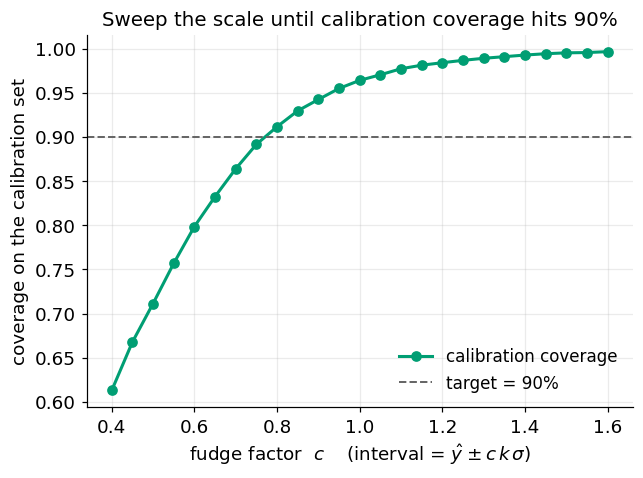

chosen c = 1.00
   calibration coverage at this c = 96.4%
   TEST coverage at this c        = 96.5%   (target = 90%)
   median half-width: raw = 0.260 dex   -> fudged = 0.260 dex


In [8]:
# Sweep the fudge factor c on the CALIBRATION set, then read coverage honestly on test.
c_grid = np.linspace(0.4, 1.6, 25)
cal_cov = np.array([empirical_coverage(y_cal_feh, y_pred_cal - c*k*sigma_cal, y_pred_cal + c*k*sigma_cal)
                    for c in c_grid])

fig, ax = plt.subplots()
ax.plot(c_grid, cal_cov, "o-", color=COLORS["rf"], label="calibration coverage")
ax.axhline(TARGET_LEVEL, ls="--", color="0.4", lw=1.3, label=f"target = {TARGET_LEVEL:.0%}")
ax.set_xlabel(r"fudge factor  $c$    (interval = $\hat y \pm c\,k\,\sigma$)")
ax.set_ylabel("coverage on the calibration set")
ax.set_title("Sweep the scale until calibration coverage hits 90%")
ax.legend()
plt.show()

# Read off the c where the calibration curve crosses the target line, then set it here:
c_fudge = 1.0    # <- your turn: set c to where the calibration curve crosses 90% (try ~0.77 for RF)

# Apply the SAME c to the TEST set and check coverage honestly.
native_lower = y_pred_native - c_fudge * k * sigma_native
native_upper = y_pred_native + c_fudge * k * sigma_native
cal_cov_c  = empirical_coverage(y_cal_feh, y_pred_cal - c_fudge*k*sigma_cal, y_pred_cal + c_fudge*k*sigma_cal)
cov_native = empirical_coverage(y_test_feh, native_lower, native_upper)
print(f"chosen c = {c_fudge:.2f}")
print(f"   calibration coverage at this c = {cal_cov_c:.1%}")
print(f"   TEST coverage at this c        = {cov_native:.1%}   (target = {TARGET_LEVEL:.0%})")
print(f"   median half-width: raw = {np.median(k*sigma_native):.3f} dex   "
      f"-> fudged = {np.median(c_fudge*k*sigma_native):.3f} dex")

## 4 · Did it work? Three questions

We judge the calibrated native interval on three things:

1. **Marginal coverage** — one number versus the 90% target. (You just got this to ~90%.)
2. **Reliability across the data** — is it honest *everywhere* (every `log g`, every `[Fe/H]`), not just
   on average?
3. **Sharpness / width** — define **width** = `upper − lower`; narrower is better, *but only if coverage
   still holds*.

The headline idea: **marginal ≠ conditional.** A method can be 90% on average yet quietly wrong for
giants or metal-poor stars. **Marginal coverage** is the overall number; **conditional coverage** is
being right *within every* subgroup. Never report only the overall number.

We'll slice along the two physical axes the forest's σ *might* be able to see:

- **surface gravity `log g`** — compact **dwarfs** (high `log g`) vs bloated, luminous **giants** (low
  `log g`, the sparse, most-extrapolated stars).
- **metallicity `[Fe/H]`** — **metal-poor** stars (low `[Fe/H]`) have the faintest metal lines, so the
  least chemical information.

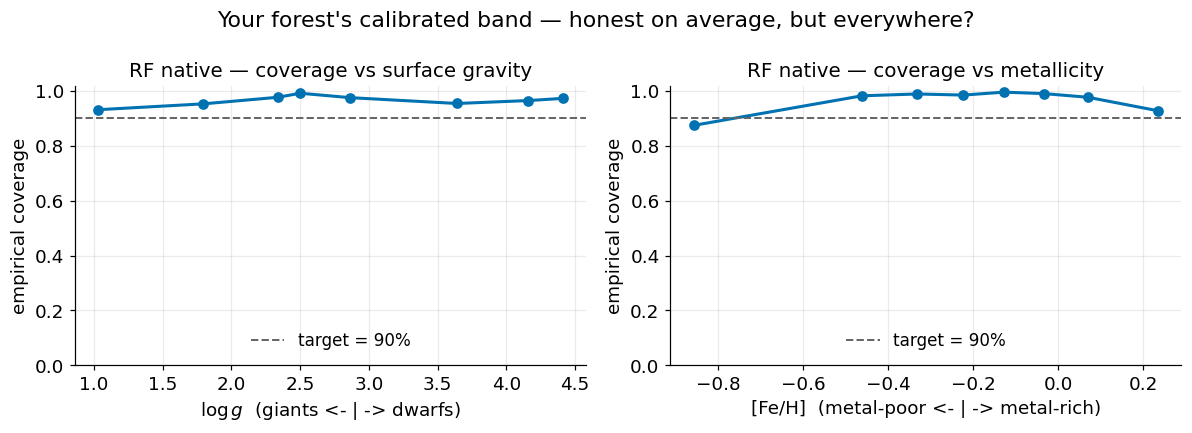

In [9]:
# Slice the FUDGED native interval's coverage by both physical axes.
# plot_reliability bins the stars (equal-count quantile bins) and shows coverage per bin vs the target.
lo_plot, hi_plot = native_lower, native_upper        # <- your turn: try native_lower_raw, native_upper_raw
                                                     #    (the un-fudged band) and compare the shape

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=logg_test, feature_name=r"$\log g$  (giants <- | -> dwarfs)", ax=axes[0])
axes[0].set_title("RF native — coverage vs surface gravity")
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <- | -> metal-rich)", ax=axes[1])
axes[1].set_title("RF native — coverage vs metallicity")
fig.suptitle("Your forest's calibrated band — honest on average, but everywhere?")
fig.tight_layout()
plt.show()
# <- look for: which bins sag BELOW the 90% line? The giants (low log g)? The metal-poor (low [Fe/H])?

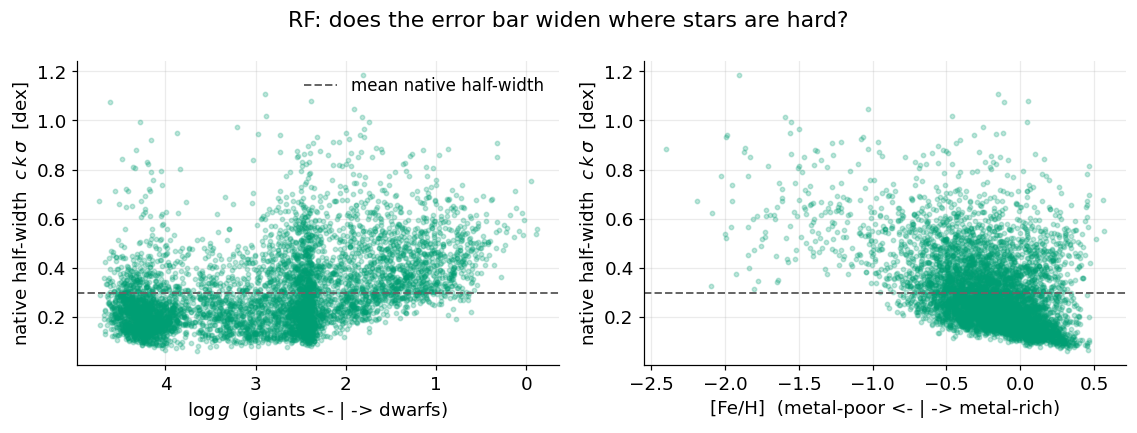

corr(sigma, -log g) = +0.43   (positive -> wider for giants)
corr(sigma, -[Fe/H]) = +0.47   (positive -> wider for metal-poor)


In [10]:
# Does the native half-width grow where the stars are hard (luminous giants, metal-poor)?
half = c_fudge * k * sigma_native
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].scatter(logg_test, half, s=8, alpha=0.25, color=COLORS["rf"])
axes[0].axhline(np.mean(half), ls="--", color="0.4", lw=1.3, label="mean native half-width")
axes[0].set_xlabel(r"$\log g$  (giants <- | -> dwarfs)")
axes[0].set_ylabel(r"native half-width  $c\,k\,\sigma$  [dex]")
axes[0].invert_xaxis(); axes[0].legend()
axes[1].scatter(feh_test, half, s=8, alpha=0.25, color=COLORS["rf"])
axes[1].axhline(np.mean(half), ls="--", color="0.4", lw=1.3)
axes[1].set_xlabel(r"[Fe/H]  (metal-poor <- | -> metal-rich)")
axes[1].set_ylabel(r"native half-width  $c\,k\,\sigma$  [dex]")
fig.suptitle("RF: does the error bar widen where stars are hard?")
fig.tight_layout()
savefig("rf_native_width_vs_logg_FeH.png"); plt.show()

# A quick number: correlation of the half-width with "hardness" (low log g, low [Fe/H]).
print(f"corr(sigma, -log g) = {np.corrcoef(sigma_native, -logg_test)[0,1]:+.2f}   "
      f"(positive -> wider for giants)")
print(f"corr(sigma, -[Fe/H]) = {np.corrcoef(sigma_native, -feh_test)[0,1]:+.2f}   "
      f"(positive -> wider for metal-poor)")
# <- look for: a cloud that drifts UP toward low log g and low [Fe/H] = the forest "knows" those are hard.

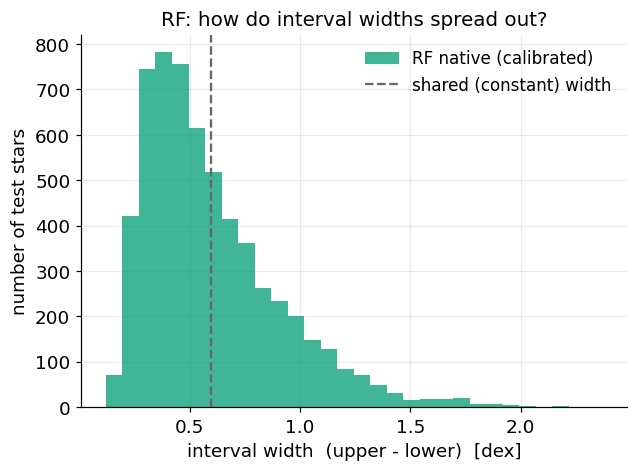

median native width = 0.519 dex   vs   constant width = 0.598 dex


In [11]:
shared_w = (shared_upper - shared_lower)        # constant -> a single spike
native_w = (native_upper - native_lower)        # varies per star
fig, ax = plt.subplots()
ax.hist(native_w, bins=30, alpha=0.75, color=COLORS["rf"], label="RF native (calibrated)")
ax.axvline(shared_w.mean(), ls="--", color="0.4", lw=1.5, label="shared (constant) width")
ax.set_xlabel("interval width  (upper - lower)  [dex]"); ax.set_ylabel("number of test stars")
ax.set_title("RF: how do interval widths spread out?")
ax.legend(); savefig("rf_native_width_hist.png"); plt.show()
print(f"median native width = {np.median(native_w):.3f} dex   vs   constant width = {shared_w[0]:.3f} dex")
# <- look for: the shared band is ONE spike (same for all); your native widths form a DISTRIBUTION.
#    Are the widest intervals the ones you'd WANT to be wide (giants, metal-poor)?

**What we just found.** Your forest's tree-spread gives a genuine **per-star** error bar, and one
tuned fudge factor lands its **marginal** coverage on ~90%. It even **widens in the right places** —
toward giants and metal-poor stars — so its conditional gap is *milder* than the blunt constant band.
But the gap doesn't vanish: the calibrated native band still **under-covers the luminous giants and
metal-poor stars** somewhat. One scalar `c` can't finish a job the per-star σ only half-did.

That residual gap is the open problem for **Notebook 4**: can we get a *guaranteed* coverage level
without trusting a Gaussian assumption (conformal prediction) — and does it close the giant / metal-poor
gap, or only the average?

## 5 · Explore (open prompts)

No single right answer — bring one annotated plot to the debrief.

1. **Aleatoric or epistemic?** Plot your per-star `sigma_native` across the **Kiel plane** (Teff vs
   `log g`). Does it grow *smoothly* with metallicity (aleatoric, heteroscedastic — the faint-metal-line
   floor) or *spike* in the sparse giant / metal-poor-halo corner (epistemic — few training trees agree
   there)? A forest's tree spread leans **epistemic** (the trees share the same noisy labels, so common
   noise cancels) — do you see that?
2. **Where is it over/under-confident?** Find the test stars whose truth fell *outside* your interval.
   Are they clustered (giants? metal-poor?) or scattered? What would you tell someone relying on those
   predictions?
3. **(Stretch) More trees, steadier σ.** The tree spread is itself a noisy estimate. Conceptually, more
   trees → a smoother σ. You loaded a 150-tree forest; if you have time, refit `make_model("rf",
   n_estimators=400)` on a small slice and compare the σ histogram. Does the *shape* of the conditional
   gap change?

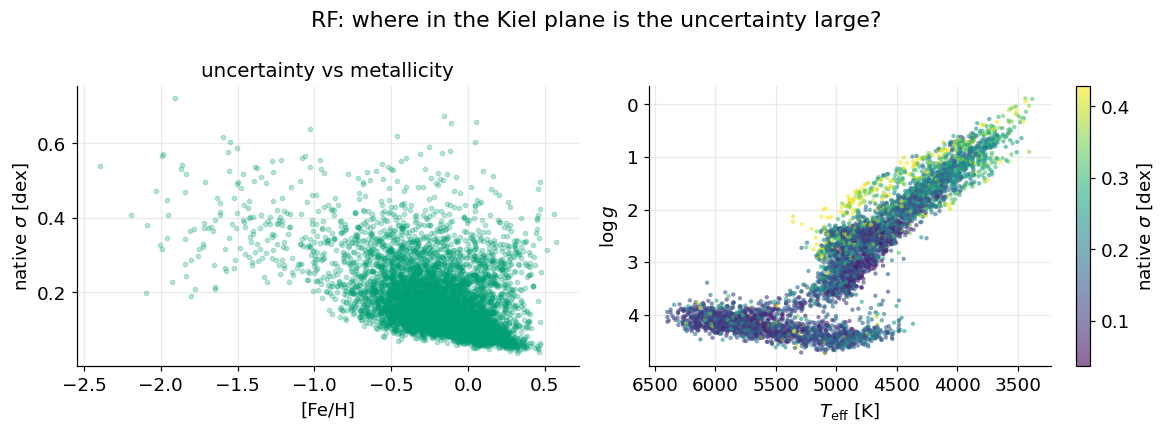

In [12]:
# A starting point for prompt 1 — extend it however you like.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(feh_test, sigma_native, s=8, alpha=0.25, color=COLORS["rf"])
axes[0].set_xlabel(r"[Fe/H]"); axes[0].set_ylabel(r"native $\sigma$ [dex]")
axes[0].set_title("uncertainty vs metallicity")
sc = axes[1].scatter(Teff_test, logg_test, c=sigma_native, s=8, alpha=0.6,
                     vmax=np.quantile(sigma_native, 0.98))
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$")
axes[1].invert_xaxis(); axes[1].invert_yaxis()
fig.colorbar(sc, ax=axes[1], label=r"native $\sigma$ [dex]")
fig.suptitle("RF: where in the Kiel plane is the uncertainty large?")
fig.tight_layout(); plt.show()
# <- your turn: which corner has the biggest sigma? The giant branch (low log g)? The metal-poor halo?
#    Smooth growth = aleatoric; a spike in the sparse corner = epistemic.

## 6 · Save your calibrated native interval for Notebook 4

Notebook 4 will **conformalize** this same random forest and compare against today's native interval, so
we save the **calibrated** native interval (the fudge factor *applied*) in the locked schema:

`outputs/rf_native_intervals.npz` with keys `y_test_true, lower, upper, target`.

We save the **§3 fudged** interval (the one that's *yours*, marginally calibrated), not the raw band.

In [13]:
path = save_outputs(f"{MODEL}_native_intervals.npz",
                    y_test_true=y_test_feh,
                    lower=native_lower,
                    upper=native_upper,
                    target=TARGET_LEVEL)
print("saved ->", path)

# Sanity re-load so you SEE the contract Notebook 4 will read:
chk = load_outputs(f"{MODEL}_native_intervals.npz")
print("keys:", list(chk.keys()),
      "| coverage re-check:",
      f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}",
      "| target:", float(chk["target"]))

saved -> /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/outputs/rf_native_intervals.npz
keys: ['y_test_true', 'lower', 'upper', 'target'] | coverage re-check: 96.5% | target: 0.9


## Recap & the cliffhanger

**What you did:** read a **per-star** uncertainty out of your random forest — the **spread across its
trees** — calibrated its scale with a single **fudge factor** tuned on the calibration set, and
stress-tested it.

**What you found:** the raw tree spread **over-covered** (~96%); one fudge factor `c ≈ 0.77` pulled
marginal coverage onto ~90%. The native band is **adaptive** (it widens toward giants and metal-poor
stars, where the forest really is less sure) and a bit **sharper** than the constant band — a real win.
**But** the **conditional gap survives**: even after the fudge, luminous giants and metal-poor stars are
still under-covered, because one scalar can't perfectly track heteroscedastic error.

**The open problem for Notebook 4:** can we get a **guaranteed** coverage level *without* a Gaussian
assumption? → **conformal prediction.** And does it fix the *giant / metal-poor* gap, or only the
average? *(Preview: it nails the average; the conditional gap is stubborn — that's the poster headline.)*

---

### What got saved today

- `outputs/rf_native_intervals.npz` — keys `y_test_true, lower, upper, target` (feeds Notebook 4).
- Figures in `figures/`: `rf_fudge_factor_sweep.png`, `rf_native_reliability.png`,
  `rf_native_width_vs_logg_FeH.png`, `rf_native_width_hist.png`.

## Stretch 1 (optional) · Input Monte Carlo — propagate the *measurement* noise

The tree spread measures the *model's* disagreement. A different, complementary uncertainty asks: **how
much would the prediction wobble if we re-measured the star?** Each star's 110 Gaia coefficients have
their own **measurement errors** — and we can propagate them by **Monte Carlo**:

1. perturb a star's coefficients by their measurement noise, `X + rng.normal(0, Xerr)`,
2. re-predict with the forest,
3. repeat many times and take the **spread** of those predictions.

The helper **`load_input_errors()`** returns the per-coefficient errors (same rows/order as `X`). Because
the pipeline works on *G-normalised* coefficients, we normalise the errors the same way (divide by
`gflux`). We run it on a **small slice** so it stays fast.

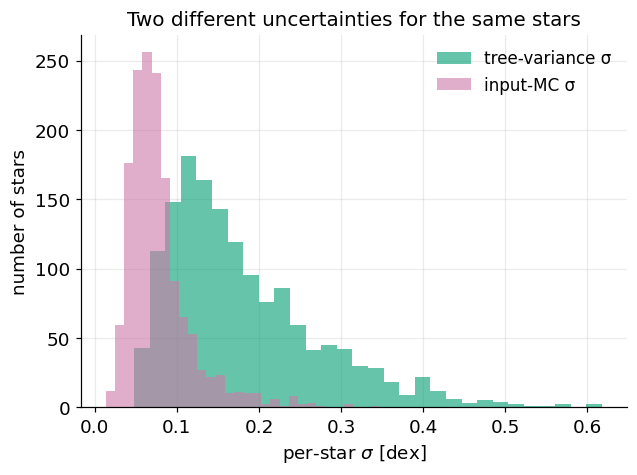

median tree-variance σ = 0.158 dex
median input-MC      σ = 0.069 dex


In [14]:
# Per-coefficient measurement errors for the stars we just loaded (raw-coefficient scale).
Xerr = load_input_errors()                 # shape (30000, 110), same rows/order as the loaded X
g = np.asarray(meta["gflux"], float).reshape(-1, 1)
Xn_err = Xerr / g                          # put the errors on the SAME normalised scale the pipeline uses
sp_err = train_cal_test_split(Xn_err, y, seed=0)   # same split -> error rows align with sp["X_test"]
Xte_err = sp_err["X_test"]

# Run input-MC on a SMALL slice so it's fast (perturb -> predict -> repeat).
n_slice = 1500                              # <- your turn: try 3000 if you have time
rng = np.random.default_rng(0)
Xte_slice  = sp["X_test"][:n_slice]
err_slice  = Xte_err[:n_slice]
N_MC = 30                                   # <- your turn: try 50 passes
sims = np.stack([pipe.predict(Xte_slice + rng.normal(0, err_slice)) for _ in range(N_MC)])  # (N_MC, n_slice)
sigma_inputMC = sims.std(axis=0)

# Compare to the tree-variance sigma on the SAME slice.
sigma_tree_slice = sigma_native[:n_slice]
fig, ax = plt.subplots()
ax.hist(sigma_tree_slice, bins=30, alpha=0.6, color=COLORS["rf"], label="tree-variance σ")
ax.hist(sigma_inputMC,    bins=30, alpha=0.6, color=COLORS["accent"], label="input-MC σ")
ax.set_xlabel(r"per-star $\sigma$ [dex]"); ax.set_ylabel("number of stars")
ax.set_title("Two different uncertainties for the same stars"); ax.legend()
plt.show()
print(f"median tree-variance σ = {np.median(sigma_tree_slice):.3f} dex")
print(f"median input-MC      σ = {np.median(sigma_inputMC):.3f} dex")
# <- look for: which is bigger? What does each one actually measure?

## Stretch 2 (optional) · Multi-label uncertainty — Teff, log g, *and* [Fe/H] at once

So far we've quantified uncertainty for **one** label, [Fe/H]. A random forest can predict **several
labels jointly** (a *multi-output* regressor) — and the tree-variance trick extends for free: each
tree now returns a *vector* per star, so the per-tree stack is `(n_trees, n_test, n_outputs)` and the
spread along the tree axis gives a σ **per label**.

We fit a *small* multi-output forest on a slice (so it's fast) and read out one native interval per
label. Watch how the calibration differs across labels — some are easy, some hard.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

labels = ["Teff", "logg", "FeH"]            # <- your turn: predict all three jointly (add "alpha"?)
n_tr = 5000                                  # small training slice so the fit is fast
Xtr = sp["X_train"][:n_tr]
Ytr = sp["y_train"][labels].to_numpy()[:n_tr]    # (n_tr, n_labels)  -- multi-output target
Yte = sp["y_test"][labels].to_numpy()

mo = make_pipeline(StandardScaler(),
                   RandomForestRegressor(n_estimators=80, min_samples_leaf=3,
                                         random_state=0, n_jobs=-1))
mo.fit(Xtr, Ytr)                             # multi-output: Y has one column per label

mo_scaler = mo.named_steps["standardscaler"]
mo_rf     = mo.named_steps["randomforestregressor"]
per_tree_mo = np.stack([t.predict(mo_scaler.transform(sp["X_test"])) for t in mo_rf.estimators_])
print("per-tree multi-output shape (n_trees, n_test, n_labels):", per_tree_mo.shape)
y_mo   = per_tree_mo.mean(axis=0)            # (n_test, n_labels)
sig_mo = per_tree_mo.std(axis=0)            # (n_test, n_labels)  -- a sigma PER LABEL

for j, lab in enumerate(labels):
    lo, hi = y_mo[:, j] - k * sig_mo[:, j], y_mo[:, j] + k * sig_mo[:, j]
    cov = empirical_coverage(Yte[:, j], lo, hi)
    print(f"  {lab:5s}: median native σ = {np.median(sig_mo[:, j]):8.3f}   raw coverage = {cov:.1%}")
# <- look for: which label is best-covered out of the box? Which needs the biggest fudge factor?

per-tree multi-output shape (n_trees, n_test, n_labels): (80, 6000, 3)
  Teff : median native σ =  115.116   raw coverage = 95.2%
  logg : median native σ =    0.376   raw coverage = 90.8%
  FeH  : median native σ =    0.186   raw coverage = 87.6%


## Further reading

- **scikit-learn — `RandomForestRegressor` (`.estimators_` is the list of fitted trees):**
  https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html — the
  per-tree spread you used comes straight from this attribute.
- **Quantile Regression Forests — Meinshausen (2006):**
  https://www.jmlr.org/papers/v7/meinshausen06a.html — the principled forest-uncertainty method that
  keeps each leaf's full target distribution (the `quantile-forest` package implements it).
- **Aleatoric vs. epistemic uncertainty — Hüllermeier & Waegeman (2021):**
  https://arxiv.org/abs/1910.09457 — the careful version of the two flavours you explored in §5.
- **Calibration, coverage, reliability — A Gentle Introduction to Conformal Prediction (Angelopoulos &
  Bates 2021):** https://arxiv.org/abs/2107.07511 — §1–2 define a prediction interval and **empirical
  coverage**, and are explicit about **marginal vs conditional** coverage (the gap your reliability plots
  exposed). The launch pad for Notebook 4.
- **The paper behind the data — Laroche & Speagle (2025, arXiv:2404.07316):**
  https://arxiv.org/abs/2404.07316 — why XP chemical information is rich for metal-rich disk stars and
  fades for the metal-poor halo (the physical root of your forest's heteroscedastic `[Fe/H]` error).
- **Deep Ensembles — Lakshminarayanan, Pritzel & Blundell (2017):**
  https://arxiv.org/abs/1612.01474 — the "spread across an ensemble = uncertainty" idea, the
  neural-net cousin of your tree-variance recipe (Student C builds this in 03c).